# Função Quadrática: Sinal, Inequações e Raízes

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`0108a_funcao_quadratica_grafico_e_propriedades.ipynb`](0108a_funcao_quadratica_grafico_e_propriedades.ipynb) (função quadrática, gráfico em parábola, discriminante Δ, fórmula de Bhaskara, vértice)

**Objetivos de aprendizagem:**
- Estudar o sinal de uma função quadrática a partir do gráfico e do discriminante.
- Resolver inequações do 2º grau.
- Usar as relações de Girard para obter soma e produto das raízes sem calculá-las.
- Determinar o sinal das raízes e comparar um número real com as raízes de uma equação do 2º grau.

**Tempo estimado:** 55 a 70 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0109a_funcao_quadratica_sinal_inequacoes_e_raizes.ipynb)

## Lucro positivo: quando vale a pena vender?

Uma empresa estima que o lucro (em milhares de reais) obtido com a venda de x centenas de um certo produto seja:

$$L(x) = -x^2 + 10x - 16$$

No notebook anterior você aprendeu a encontrar o **lucro máximo** dessa empresa — o vértice da parábola. Mas o gerente financeiro faz outra pergunta, mais prática:

> **Para quais quantidades vendidas a empresa efetivamente tem lucro positivo (e não prejuízo)?**

Não basta saber o ponto de lucro máximo: é preciso saber o **intervalo inteiro** de x onde L(x) > 0 — fora dele, a empresa perde dinheiro. Ainda não temos essa ferramenta pronta. Vamos construí-la ao longo deste notebook e, na seção de Inequações, voltar para responder exatamente essa pergunta.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def funcao_quadratica(x, a: float, b: float, c: float):
    '''Calcula f(x) = a*x^2 + b*x + c.'''
    return a * x**2 + b * x + c


def raizes_reais(a: float, b: float, c: float):
    '''Retorna (delta, raizes) de ax²+bx+c=0, com raizes ordenadas quando existem.'''
    delta = b**2 - 4 * a * c
    if delta > 0:
        r1 = float((-b - np.sqrt(delta)) / (2 * a))
        r2 = float((-b + np.sqrt(delta)) / (2 * a))
        return delta, tuple(sorted((r1, r2)))
    if delta == 0:
        return delta, (float(-b / (2 * a)),)
    return delta, ()


x_sym = sp.symbols("x")

## 1. Sinal da Função

📌 Estudar o **sinal** de f(x) = ax² + bx + c é determinar para quais valores de x temos f(x) > 0, f(x) = 0 ou f(x) < 0. O sinal depende da combinação de duas coisas: o sinal de **a** (concavidade) e o valor de **Δ** (quantidade de zeros).

| | Δ > 0 | Δ = 0 | Δ < 0 |
|---|---|---|---|
| **a > 0** | negativa entre as raízes, positiva fora | positiva em toda parte, exceto zero na raiz dupla | positiva em toda parte |
| **a < 0** | positiva entre as raízes, negativa fora | negativa em toda parte, exceto zero na raiz dupla | negativa em toda parte |

O gráfico abaixo mostra os seis casos da tabela: cada coluna é um valor de Δ, cada linha um sinal de a. As regiões onde f(x) > 0 estão sombreadas de verde e onde f(x) < 0 estão sombreadas de vermelho.

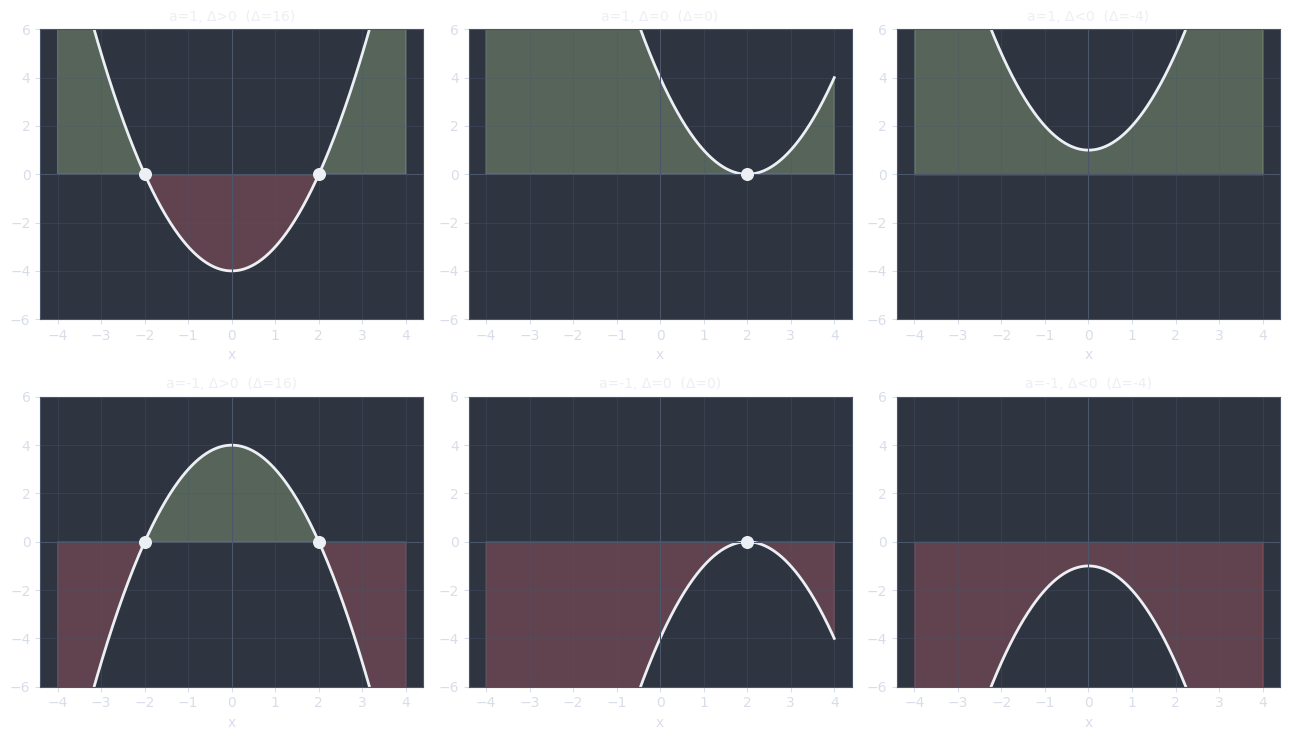

In [2]:
casos_sinal = [
    ("a=1, Δ>0", 1, 0, -4),
    ("a=1, Δ=0", 1, -4, 4),
    ("a=1, Δ<0", 1, 0, 1),
    ("a=-1, Δ>0", -1, 0, 4),
    ("a=-1, Δ=0", -1, 4, -4),
    ("a=-1, Δ<0", -1, 0, -1),
]

fig, eixos = plt.subplots(2, 3, figsize=(13, 7.5))
xs_sinal = np.linspace(-4, 4, 400)

for eixo, (titulo, a_c, b_c, c_c) in zip(eixos.flat, casos_sinal):
    estilizar_eixo(eixo)
    ys = funcao_quadratica(xs_sinal, a_c, b_c, c_c)
    eixo.fill_between(xs_sinal, ys, 0, where=(ys >= 0), color=COR_DESTAQUE, alpha=0.35, interpolate=True)
    eixo.fill_between(xs_sinal, ys, 0, where=(ys <= 0), color=COR_ALERTA, alpha=0.35, interpolate=True)
    eixo.plot(xs_sinal, ys, color=NORD_TEXTO, linewidth=2)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.8)
    eixo.axvline(0, color=NORD_LINHA, linewidth=0.8)

    delta_c, raizes_c = raizes_reais(a_c, b_c, c_c)
    eixo.scatter(raizes_c, [0] * len(raizes_c), s=70, color=NORD_TEXTO, zorder=3)
    eixo.set_ylim(-6, 6)
    eixo.set_title(f"{titulo}  (Δ={delta_c:g})", color=NORD_TEXTO, fontsize=10)
    eixo.set_xlabel("x", color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** mexa nos sliders de a, b e c — o gráfico recalcula Δ e atualiza as regiões de sinal positivo (verde) e negativo (vermelho) em tempo real.

In [ ]:
def explorar_sinal(a: float, b: float, c: float) -> None:
    if a == 0:
        print("a = 0 -> não é função quadrática")
        return

    delta, raizes = raizes_reais(a, b, c)
    xs = np.linspace(-10, 10, 400)
    ys = funcao_quadratica(xs, a, b, c)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.fill_between(xs, ys, 0, where=(ys >= 0), color=COR_DESTAQUE, alpha=0.35, interpolate=True)
    ax.fill_between(xs, ys, 0, where=(ys <= 0), color=COR_ALERTA, alpha=0.35, interpolate=True)
    ax.plot(xs, ys, color=NORD_TEXTO, linewidth=2.2)
    ax.scatter(raizes, [0] * len(raizes), s=90, color=NORD_TEXTO, zorder=3)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)

    y_min = min(ys.min(), -1)
    y_max = max(ys.max(), 1)
    ax.set_ylim(y_min - 1, y_max + 1)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"f(x) = {a:g}x² + {b:g}x + {c:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(f"Δ = {delta:g}  |  raízes: {tuple(round(r, 2) for r in raizes)}")


widgets.interact(
    explorar_sinal,
    a=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=-2.0, min=-10, max=10, step=1, description="b:"),
    c=widgets.FloatSlider(value=-3.0, min=-10, max=10, step=1, description="c:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=3.0, min=-3.0, step=0.5), FloatSlider(value…

<function __main__.explorar_sinal(a: float, b: float, c: float) -> None>

**Pergunta de checagem:** Se Δ < 0 e a > 0, qual é o sinal de f(x) para todo x real?

## 2. Inequações do 2º Grau

📌 Resolver uma inequação como ax² + bx + c > 0 (ou <, ≥, ≤) é justamente encontrar o **conjunto solução** do estudo de sinal feito no bloco anterior.

**Método passo a passo:**
1. Calcular Δ e as raízes (se existirem)
2. Determinar a concavidade (sinal de a)
3. Usar a tabela de sinal para escrever o intervalo-solução

**Exemplo 1 (Δ > 0):** resolver x² - 2x - 3 < 0.

In [4]:
a1, b1, c1 = 1, -2, -3
delta1, raizes1 = raizes_reais(a1, b1, c1)
print(f"Δ = {delta1:g}  ->  raízes: {raizes1}")
print(f"a = {a1} > 0  ->  concavidade para cima  ->  negativa ENTRE as raízes")
print(f"solução: {raizes1[0]:g} < x < {raizes1[1]:g}")

Δ = 16  ->  raízes: (-1.0, 3.0)
a = 1 > 0  ->  concavidade para cima  ->  negativa ENTRE as raízes
solução: -1 < x < 3


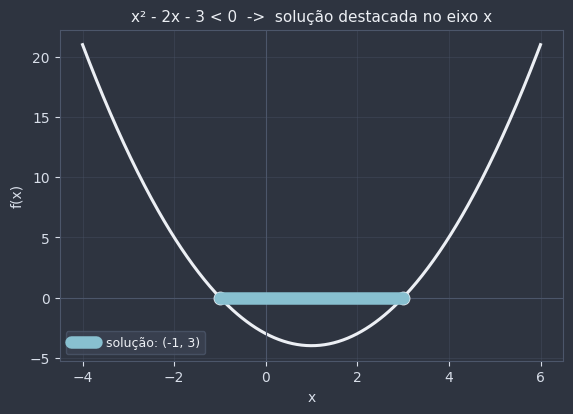

In [5]:
def grafico_solucao_inequacao(a, b, c, titulo, cor_faixa=COR_PONTO, xlim=None):
    '''Plota f(x) e destaca com uma faixa espessa sobre o eixo x a região de sinal positivo.'''
    delta, raizes = raizes_reais(a, b, c)
    lim = xlim or (min(raizes, default=-5) - 3, max(raizes, default=5) + 3)
    xs = np.linspace(*lim, 400)
    ys = funcao_quadratica(xs, a, b, c)

    fig, ax = plt.subplots(figsize=(6.5, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=NORD_TEXTO, linewidth=2.2)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.scatter(raizes, [0] * len(raizes), s=80, color=NORD_TEXTO, zorder=3)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    return fig, ax, delta, raizes


fig, ax, delta1, raizes1 = grafico_solucao_inequacao(
    a1, b1, c1, "x² - 2x - 3 < 0  ->  solução destacada no eixo x"
)
ax.plot(raizes1, [0, 0], color=COR_PONTO, linewidth=9, solid_capstyle="round", zorder=4,
        label=f"solução: ({raizes1[0]:g}, {raizes1[1]:g})")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
plt.show()

**Exemplo 2 (casos especiais com Δ ≤ 0):** quando Δ ≤ 0, a solução pode ser **todo ℝ**, **vazia** ou **ℝ menos um ponto** — sem intervalo "normal" nenhum. Três minicasos:

- g(x) = x² + x + 1 > 0 → Δ = -3 < 0, a > 0 → positiva sempre → solução é **todo ℝ**
- h(x) = x² + x + 1 < 0 → mesma função, inequação oposta → **nenhum x** satisfaz → solução é o **conjunto vazio**
- p(x) = x² - 6x + 9 > 0 → Δ = 0, a > 0 → positiva em toda parte, exceto zero na raiz dupla x=3 → solução é **ℝ - {3}**

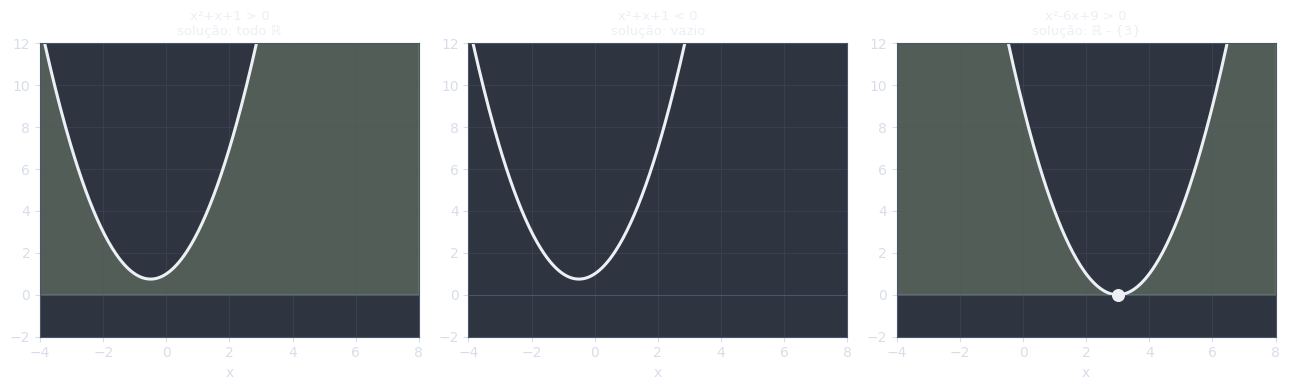

In [6]:
casos_especiais = [
    ("x²+x+1 > 0\nsolução: todo ℝ", 1, 1, 1, True),
    ("x²+x+1 < 0\nsolução: vazio", 1, 1, 1, False),
    ("x²-6x+9 > 0\nsolução: ℝ - {3}", 1, -6, 9, True),
]

fig, eixos = plt.subplots(1, 3, figsize=(13, 4))
xs_esp = np.linspace(-4, 8, 300)

for eixo, (titulo, a_c, b_c, c_c, positiva) in zip(eixos, casos_especiais):
    estilizar_eixo(eixo)
    ys = funcao_quadratica(xs_esp, a_c, b_c, c_c)
    _, raizes_c = raizes_reais(a_c, b_c, c_c)
    cor_faixa = COR_DESTAQUE if positiva else COR_ALERTA
    eixo.plot(xs_esp, ys, color=NORD_TEXTO, linewidth=2.2)
    eixo.fill_between(xs_esp, ys, 0, where=(ys >= 0) if positiva else (ys < 0),
                       color=cor_faixa, alpha=0.3, interpolate=True)
    eixo.scatter(raizes_c, [0] * len(raizes_c), s=70, color=NORD_TEXTO, zorder=3)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.8)
    eixo.set_ylim(-2, 12)
    eixo.set_xlim(-4, 8)
    eixo.set_title(titulo, color=NORD_TEXTO, fontsize=9.5)
    eixo.set_xlabel("x", color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

**Retomando o gancho:** vamos resolver L(x) = -x² + 10x - 16 > 0, a pergunta do lucro positivo.

Δ = 36  ->  raízes: (2.0, 8.0)
a = -1 < 0  ->  concavidade para baixo  ->  positiva ENTRE as raízes
solução: 2 < x < 8
em unidades vendidas (x em centenas): entre 200 e 800 unidades


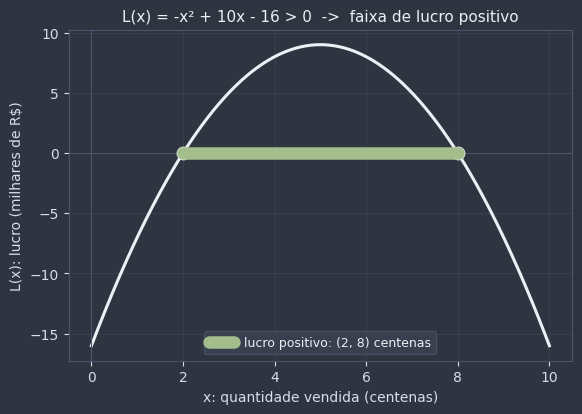

In [7]:
a_l, b_l, c_l = -1, 10, -16
delta_l, raizes_l = raizes_reais(a_l, b_l, c_l)
print(f"Δ = {delta_l:g}  ->  raízes: {raizes_l}")
print(f"a = {a_l} < 0  ->  concavidade para baixo  ->  positiva ENTRE as raízes")
print(f"solução: {raizes_l[0]:g} < x < {raizes_l[1]:g}")
print(f"em unidades vendidas (x em centenas): entre {raizes_l[0]*100:g} e {raizes_l[1]*100:g} unidades")

fig, ax, _, _ = grafico_solucao_inequacao(
    a_l, b_l, c_l, "L(x) = -x² + 10x - 16 > 0  ->  faixa de lucro positivo", xlim=(0, 10)
)
ax.plot(raizes_l, [0, 0], color=COR_DESTAQUE, linewidth=9, solid_capstyle="round", zorder=4,
        label=f"lucro positivo: ({raizes_l[0]:g}, {raizes_l[1]:g}) centenas")
ax.set_xlabel("x: quantidade vendida (centenas)", color=NORD_TEXTO_SEC)
ax.set_ylabel("L(x): lucro (milhares de R$)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
plt.show()

**Pergunta de checagem:** Por que uma inequação com Δ < 0 e a > 0 não tem solução (para "< 0") ou vale para todo x real (para "> 0")?

## 3. Relações de Girard (Soma e Produto das Raízes)

📌 As **relações de Girard** permitem obter a soma e o produto das raízes de ax² + bx + c = 0 sem precisar calculá-las individualmente:

$$S = x_1 + x_2 = -\frac{b}{a}, \qquad P = x_1 \cdot x_2 = \frac{c}{a}$$

**Dedução rápida:** partindo da forma fatorada a(x-x₁)(x-x₂) e expandindo:

$$a(x-x_1)(x-x_2) = ax^2 - a(x_1+x_2)x + ax_1x_2$$

Comparando termo a termo com ax² + bx + c: o coeficiente de x dá -a(x₁+x₂) = b, ou seja S = -b/a; o termo constante dá ax₁x₂ = c, ou seja P = c/a.

Vamos conferir com sympy, comparando a expansão simbólica com a forma geral.

In [8]:
a_g, x1_g, x2_g = sp.symbols("a x1 x2")
forma_fatorada = sp.expand(a_g * (x_sym - x1_g) * (x_sym - x2_g))
print(f"a(x-x1)(x-x2) expandido: {forma_fatorada}")
print("coeficiente de x:", forma_fatorada.coeff(x_sym, 1), " -> compare com b = -a(x1+x2)")
print("termo constante:  ", forma_fatorada.coeff(x_sym, 0), " -> compare com c = a*x1*x2")

a(x-x1)(x-x2) expandido: a*x**2 - a*x*x1 - a*x*x2 + a*x1*x2
coeficiente de x: -a*x1 - a*x2  -> compare com b = -a(x1+x2)
termo constante:   a*x1*x2  -> compare com c = a*x1*x2


**Verificação numérica:** para f(x) = 2x² - 3x - 5, calculamos as raízes por Bhaskara e conferimos que x₁+x₂ e x₁·x₂ batem com -b/a e c/a.

raízes por Bhaskara: x1=-1, x2=2.5
S = x1+x2 = 1.5   |   -b/a = 1.5
P = x1*x2 = -2.5   |    c/a = -2.5


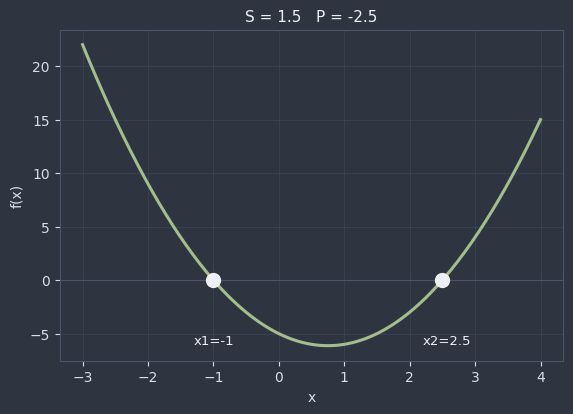

In [9]:
a3, b3, c3 = 2, -3, -5
delta3, raizes3 = raizes_reais(a3, b3, c3)
x1_3, x2_3 = raizes3

S_bhaskara = x1_3 + x2_3
P_bhaskara = x1_3 * x2_3
S_girard = sp.Rational(-b3, a3)
P_girard = sp.Rational(c3, a3)

print(f"raízes por Bhaskara: x1={x1_3:g}, x2={x2_3:g}")
print(f"S = x1+x2 = {S_bhaskara:g}   |   -b/a = {float(S_girard):g}")
print(f"P = x1*x2 = {P_bhaskara:g}   |    c/a = {float(P_girard):g}")

fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
xs3 = np.linspace(-3, 4, 200)
ax.plot(xs3, funcao_quadratica(xs3, a3, b3, c3), color=COR_DESTAQUE, linewidth=2.2)
ax.scatter([x1_3, x2_3], [0, 0], s=100, color=NORD_TEXTO, zorder=3)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.annotate(f"x1={x1_3:g}", xy=(x1_3, 0), xytext=(x1_3 - 0.3, -6), color=NORD_TEXTO, fontsize=9.5)
ax.annotate(f"x2={x2_3:g}", xy=(x2_3, 0), xytext=(x2_3 - 0.3, -6), color=NORD_TEXTO, fontsize=9.5)
ax.set_title(f"S = {S_bhaskara:g}   P = {P_bhaskara:g}", color=NORD_TEXTO, fontsize=11)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
plt.show()

**Pergunta de checagem:** É possível saber a soma e o produto das raízes sem calcular Δ nem as raízes? Como?

## 4. Sinais das Raízes da Equação do 2º Grau

📌 Combinando Δ, S e P, dá para determinar os sinais das duas raízes **sem resolver a equação**:

| Condição | Conclusão |
|---|---|
| Δ ≥ 0 e P > 0 e S > 0 | as duas raízes são positivas |
| Δ ≥ 0 e P > 0 e S < 0 | as duas raízes são negativas |
| Δ ≥ 0 e P < 0 | raízes de sinais opostos |
| Δ ≥ 0 e P = 0 | uma das raízes é zero |

Três exemplos numéricos, um para cada uma das três primeiras linhas:

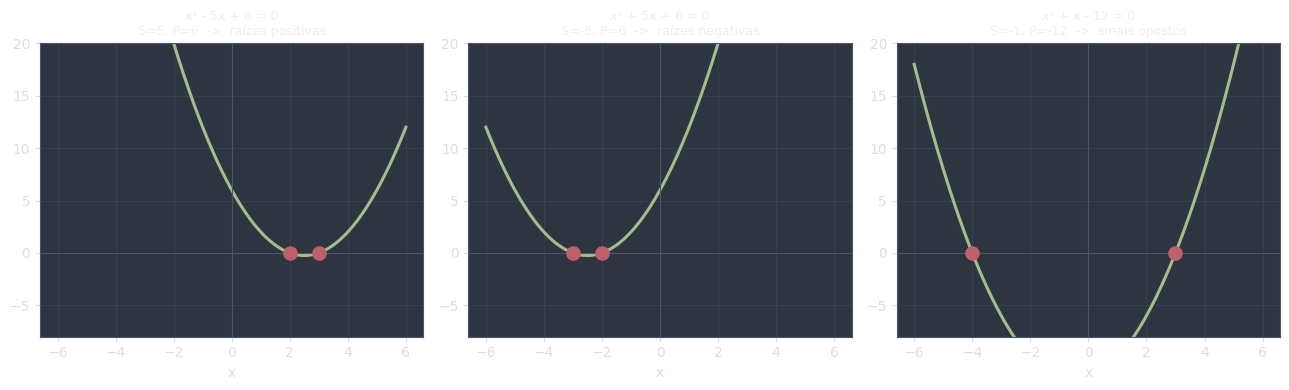

In [10]:
exemplos_sinais_raizes = [
    ("x² - 5x + 6 = 0", 1, -5, 6),
    ("x² + 5x + 6 = 0", 1, 5, 6),
    ("x² + x - 12 = 0", 1, 1, -12),
]

fig, eixos = plt.subplots(1, 3, figsize=(13, 4))
xs_raizes = np.linspace(-6, 6, 300)

for eixo, (titulo, a_c, b_c, c_c) in zip(eixos, exemplos_sinais_raizes):
    estilizar_eixo(eixo)
    delta_c, raizes_c = raizes_reais(a_c, b_c, c_c)
    S_c, P_c = sp.Rational(-b_c, a_c), sp.Rational(c_c, a_c)

    if P_c > 0 and S_c > 0:
        conclusao = "raízes positivas"
    elif P_c > 0 and S_c < 0:
        conclusao = "raízes negativas"
    else:
        conclusao = "sinais opostos"

    ys = funcao_quadratica(xs_raizes, a_c, b_c, c_c)
    eixo.plot(xs_raizes, ys, color=COR_DESTAQUE, linewidth=2.2)
    eixo.scatter(raizes_c, [0] * len(raizes_c), s=90, color=COR_ALERTA, zorder=3)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.8)
    eixo.axvline(0, color=NORD_LINHA, linewidth=0.8)
    eixo.set_ylim(-8, 20)
    eixo.set_title(f"{titulo}\nS={int(S_c)}, P={int(P_c)}  ->  {conclusao}", color=NORD_TEXTO, fontsize=9)
    eixo.set_xlabel("x", color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

**Pergunta de checagem:** Se P < 0, o que isso garante sobre os sinais das duas raízes, independentemente do valor de S?

## 5. Teorema: Comparação de um Número Real com as Raízes

📌 Este teorema generaliza a ideia do bloco anterior: em vez de comparar as raízes com **zero**, comparamos com um número real k qualquer.

**Enunciado (informal):** dado f(x) = ax² + bx + c com raízes reais x₁ ≤ x₂, e um número real k:

- Se **a·f(k) < 0**, então k está **entre** as raízes (x₁ < k < x₂)
- Se **a·f(k) > 0**, então k está **fora** do intervalo das raízes (usar o vértice/eixo de simetria para saber de qual lado)
- Se **a·f(k) = 0**, então k é uma das raízes

O grande ganho é **não precisar calcular x₁ e x₂** — basta avaliar o sinal de a·f(k). Três exemplos com f(x) = x² - 4x + 1 (a = 1):

In [11]:
a5, b5, c5 = 1, -4, 1
delta5, raizes5 = raizes_reais(a5, b5, c5)
vertice_x5 = -b5 / (2 * a5)
print(f"Δ = {delta5:g}  ->  raízes: {[round(r, 2) for r in raizes5]}  (vértice em x = {vertice_x5:g})")

for k in (1, 5, -1):
    fk = funcao_quadratica(k, a5, b5, c5)
    afk = a5 * fk
    if afk < 0:
        posicao = "ENTRE as raízes"
    elif afk == 0:
        posicao = "é uma das raízes"
    else:
        lado = "à esquerda de x1" if k < vertice_x5 else "à direita de x2"
        posicao = f"FORA do intervalo ({lado})"
    print(f"k={k:>2}: f(k)={fk:>6.2f}  a*f(k)={afk:>6.2f}  ->  k está {posicao}")

Δ = 12  ->  raízes: [0.27, 3.73]  (vértice em x = 2)
k= 1: f(k)= -2.00  a*f(k)= -2.00  ->  k está ENTRE as raízes
k= 5: f(k)=  6.00  a*f(k)=  6.00  ->  k está FORA do intervalo (à direita de x2)
k=-1: f(k)=  6.00  a*f(k)=  6.00  ->  k está FORA do intervalo (à esquerda de x1)


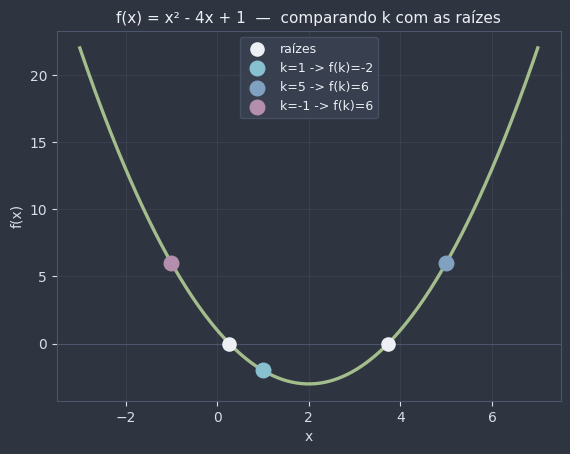

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
xs5 = np.linspace(-3, 7, 300)
ax.plot(xs5, funcao_quadratica(xs5, a5, b5, c5), color=COR_DESTAQUE, linewidth=2.4)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.scatter(raizes5, [0, 0], s=90, color=NORD_TEXTO, zorder=3, label="raízes")

for k, cor in zip((1, 5, -1), (COR_PONTO, COR_SECUNDARIA, COR_EXTRA)):
    fk = funcao_quadratica(k, a5, b5, c5)
    ax.scatter([k], [fk], s=110, color=cor, zorder=4, label=f"k={k} -> f(k)={fk:g}")

ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
ax.set_title("f(x) = x² - 4x + 1  —  comparando k com as raízes", color=NORD_TEXTO, fontsize=11)
plt.show()

🕹️ **Widget interativo:** mexa no slider de k e observe o ponto (k, f(k)) se mover ao longo da curva — a mensagem abaixo diz se k está entre as raízes, fora do intervalo, ou é uma raiz.

In [ ]:
def explorar_comparacao_k(k: float) -> None:
    a_k, b_k, c_k = 1, -4, 1
    delta_k, raizes_k = raizes_reais(a_k, b_k, c_k)
    vertice_x_k = -b_k / (2 * a_k)
    fk = funcao_quadratica(k, a_k, b_k, c_k)
    afk = a_k * fk

    if afk < 0:
        mensagem = "k está ENTRE as raízes"
    elif afk == 0:
        mensagem = "k é uma das raízes"
    else:
        lado = "à esquerda de x1" if k < vertice_x_k else "à direita de x2"
        mensagem = f"k está FORA do intervalo das raízes ({lado})"

    xs = np.linspace(-3, 7, 300)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, funcao_quadratica(xs, a_k, b_k, c_k), color=COR_DESTAQUE, linewidth=2.4)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.scatter(raizes_k, [0] * len(raizes_k), s=90, color=NORD_TEXTO, zorder=3)
    ax.scatter([k], [fk], s=120, color=COR_PONTO, zorder=4)
    ax.set_ylim(-4, 10)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("f(x)", color=NORD_TEXTO_SEC)
    ax.set_title(f"k = {k:.2f}   f(k) = {fk:.2f}   a·f(k) = {afk:.2f}", color=NORD_TEXTO, fontsize=11)
    plt.show()

    print(mensagem)


widgets.interact(
    explorar_comparacao_k,
    k=widgets.FloatSlider(value=1.0, min=-3, max=7, step=0.1, description="k:"),
)

interactive(children=(FloatSlider(value=1.0, description='k:', max=7.0, min=-3.0), Output()), _dom_classes=('w…

<function __main__.explorar_comparacao_k(k: float) -> None>

**Pergunta de checagem:** Se a·f(k) < 0, o que isso garante sobre a posição de k em relação às raízes?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Sinal de f | depende do sinal de a e do valor de Δ (6 casos — ver tabela da seção 1) |
| Inequação do 2º grau | resolvida pelo estudo de sinal da função associada |
| Girard | S = x₁+x₂ = -b/a  \|  P = x₁·x₂ = c/a |
| Sinais das raízes | P<0 → sinais opostos \| P>0 e S>0 → ambas positivas \| P>0 e S<0 → ambas negativas |
| Teorema da comparação | analisar o sinal de a·f(k) para localizar k em relação às raízes |

## Exercícios

**Básico**
1. Estude o sinal de f(x) = x² - x - 6 (identifique os intervalos onde é positiva, negativa e zero).
2. Resolva a inequação -x² + 4x - 3 ≥ 0.

**Intermediário**
3. Sem resolver a equação, determine o sinal das raízes de 2x² - 7x + 3 = 0 usando S e P.
4. Determine para quais valores de m a equação x² - mx + (m+3) = 0 tem duas raízes reais e distintas.

**Desafio**
5. Sem calcular as raízes de f(x) = x² - 5x + 2, determine se k=1 está entre as raízes, e se k=10 está entre as raízes.
6. (Contextualizado) Retome o problema do lucro L(x) = -x² + 10x - 16 do início do notebook: para quais quantidades vendidas a empresa tem lucro de pelo menos 5 (ou seja, resolva L(x) ≥ 5)?

Gabarito completo com resolução passo a passo em [`0109b_funcao_quadratica_sinal_inequacoes_e_raizes_gabarito.ipynb`](0109b_funcao_quadratica_sinal_inequacoes_e_raizes_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: estude o sinal de f(x) = x² - x - 6. Preencha delta_ex1,
# as duas raízes (raiz_menor_ex1 <= raiz_maior_ex1) e o sinal de f(x) fora do
# intervalo das raízes (sinal_fora_ex1) e entre as raízes (sinal_entre_ex1),
# como as strings "positivo" ou "negativo".
a_ex1, b_ex1, c_ex1 = 1, -1, -6

delta_ex1 = ...
raiz_menor_ex1 = ...
raiz_maior_ex1 = ...
sinal_fora_ex1 = ...
sinal_entre_ex1 = ...

print(delta_ex1, raiz_menor_ex1, raiz_maior_ex1, sinal_fora_ex1, sinal_entre_ex1)

In [ ]:
# Verificação
assert delta_ex1 == 25, "Tente de novo, revise o passo 1: Δ = b² - 4ac = (-1)² - 4(1)(-6)."
assert (raiz_menor_ex1, raiz_maior_ex1) == (-2, 3), (
    "Tente de novo, revise o passo 2: use Bhaskara com Δ = 25 (seção 1 - Sinal)."
)
assert sinal_fora_ex1 == "positivo", (
    "Tente de novo, revise o passo 3: a=1>0 e Δ>0 -> positiva FORA das raízes (tabela da seção 1)."
)
assert sinal_entre_ex1 == "negativo", (
    "Tente de novo, revise o passo 3: a=1>0 e Δ>0 -> negativa ENTRE as raízes (tabela da seção 1)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: resolva a inequação -x² + 4x - 3 >= 0. Preencha os limites
# do intervalo-solução (sol_menor_ex2 <= sol_maior_ex2) -- a solução é o
# intervalo fechado [sol_menor_ex2, sol_maior_ex2].
a_ex2, b_ex2, c_ex2 = -1, 4, -3

sol_menor_ex2 = ...
sol_maior_ex2 = ...

print(sol_menor_ex2, sol_maior_ex2)

In [ ]:
# Verificação
assert (sol_menor_ex2, sol_maior_ex2) == (1, 3), (
    "Tente de novo, revise: Δ=4, raízes 1 e 3; a=-1<0 -> positiva ENTRE as raízes "
    "(seção 2 - Inequações)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: sem resolver a equação 2x² - 7x + 3 = 0, calcule
# S (soma_ex3) e P (produto_ex3) com as relações de Girard e diga o sinal das
# raízes em sinal_raizes_ex3 ("positivas", "negativas" ou "opostas").
a_ex3, b_ex3, c_ex3 = 2, -7, 3

soma_ex3 = ...
produto_ex3 = ...
sinal_raizes_ex3 = ...

print(soma_ex3, produto_ex3, sinal_raizes_ex3)

In [ ]:
# Verificação
assert soma_ex3 == sp.Rational(7, 2), "Tente de novo, revise o passo 1: S = -b/a (seção 3 - Girard)."
assert produto_ex3 == sp.Rational(3, 2), "Tente de novo, revise o passo 2: P = c/a (seção 3 - Girard)."
assert sinal_raizes_ex3 == "positivas", (
    "Tente de novo, revise o passo 3: S>0 e P>0 -> as duas raízes são positivas (seção 4)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: determine para quais valores de m a equação
# x² - mx + (m+3) = 0 tem duas raízes reais e distintas (Δ > 0). Δ(m) é uma
# função quadrática de m; encontre suas duas raízes m_menor_ex4 <= m_maior_ex4
# e diga se a solução é "dentro" ou "fora" desse intervalo.
m_sym = sp.symbols("m")
delta_m_ex4 = m_sym**2 - 4 * (m_sym + 3)  # Δ em função de m

m_menor_ex4 = ...
m_maior_ex4 = ...
tipo_solucao_ex4 = ...  # "dentro" ou "fora" do intervalo [m_menor_ex4, m_maior_ex4]

print(m_menor_ex4, m_maior_ex4, tipo_solucao_ex4)

In [ ]:
# Verificação
assert (m_menor_ex4, m_maior_ex4) == (-2, 6), (
    "Tente de novo, revise o passo 1: Δ(m) = m² - 4m - 12 = (m-6)(m+2); "
    "raízes de Δ(m)=0 são -2 e 6 (seção 2 - Inequações)."
)
assert tipo_solucao_ex4 == "fora", (
    "Tente de novo, revise o passo 2: Δ(m) é uma parábola com concavidade para cima "
    "(coeficiente de m² é 1 > 0) -> positiva FORA do intervalo das raízes."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: sem calcular as raízes de f(x) = x² - 5x + 2, use o
# teorema da comparação (seção 5) para decidir se k=1 e k=10 estão entre as
# raízes. Preencha afk1_ex5 e afk2_ex5 com o valor de a*f(k) para cada k, e
# posicao_k1_ex5/posicao_k2_ex5 com "entre" ou "fora".
a_ex5, b_ex5, c_ex5 = 1, -5, 2

afk1_ex5 = ...  # a * f(1)
afk2_ex5 = ...  # a * f(10)
posicao_k1_ex5 = ...
posicao_k2_ex5 = ...

print(afk1_ex5, afk2_ex5, posicao_k1_ex5, posicao_k2_ex5)

In [ ]:
# Verificação
assert afk1_ex5 == -2, "Tente de novo, revise o passo 1: a*f(1) = 1*(1-5+2) (seção 5 - Teorema da comparação)."
assert afk2_ex5 == 52, "Tente de novo, revise o passo 2: a*f(10) = 1*(100-50+2)."
assert posicao_k1_ex5 == "entre", "Tente de novo, revise: a*f(1) < 0 -> k=1 está ENTRE as raízes."
assert posicao_k2_ex5 == "fora", "Tente de novo, revise: a*f(10) > 0 -> k=10 está FORA do intervalo."
print("Certo!")

In [ ]:
# Exercício Desafio 6 (contextualizado): retomando L(x) = -x² + 10x - 16,
# resolva L(x) >= 5 e encontre os limites do intervalo-solução em centenas de
# unidades (sol_menor_ex6 <= sol_maior_ex6).
a_ex6, b_ex6, c_ex6 = -1, 10, -16

sol_menor_ex6 = ...
sol_maior_ex6 = ...

print(sol_menor_ex6, sol_maior_ex6)

In [ ]:
# Verificação
assert (sol_menor_ex6, sol_maior_ex6) == (3, 7), (
    "Tente de novo, revise: L(x)>=5 -> -x²+10x-21>=0 -> x²-10x+21<=0 -> raízes 3 e 7; "
    "a=1>0 -> negativa ENTRE as raízes (seção 2 - Inequações)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0108a_funcao_quadratica_grafico_e_propriedades.ipynb`](0108a_funcao_quadratica_grafico_e_propriedades.ipynb) (função quadrática, gráfico, discriminante Δ, Bhaskara, vértice)

**Isso será usado em:**
- 📌 Inequações e sistemas envolvendo funções compostas
- [`08_analise_combinatoria_e_probabilidade/`](../08_analise_combinatoria_e_probabilidade/) (problemas de otimização com restrições)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (estudo de sinal para análise de crescimento)